In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import json
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.load_cluster_data import load_cluster_config
from src.optical_pipeline.utils.colors import get_color_columns

cluster = "NGC_6809"

In [2]:
params = load_cluster_config(cluster)

path = params["path_optical"]
distance_parsecs = params["distance_parsecs"]


Mag_min = -50
Mag_max = 50
RMS_max = 1
Fit_max = 1.5
Sharp_min = -2
Sharp_max = 2
CM_min = 80
bins_division = 20
min_count = 2
min_step = 2
maximum_lenght_MSTO = 0.70
bluer_limit = 0.5
significantly_bluer_limit = 1.0
redder_limit = 0.5
significantly_redder_limit = 1.0

# Step 1: load_optical_data

We load all the optical data we need and assign the column names.

In [3]:
COLUMNS = [
    "X", "Y",
    "275_Mag", "275_RMS", "275_Fit", "275_Sharp", "275_exp_found", "275_exp_well",
    "336_Mag", "336_RMS", "336_Fit", "336_Sharp", "336_exp_found", "336_exp_well",
    "438_Mag", "438_RMS", "438_Fit", "438_Sharp", "438_exp_found", "438_exp_well",
    "606_Mag", "606_RMS", "606_Fit", "606_Sharp", "606_exp_found", "606_exp_well",
    "814_Mag", "814_RMS", "814_Fit", "814_Sharp", "814_exp_found", "814_exp_well",
    "Cluster_Membership",
    "RA", "Decl",
    "Id",
    "Iteration_found"
]

df = pd.read_csv(
    path,
    sep=r"\s+",
    header=None
)

if df.shape[1] != len(COLUMNS):
    raise ValueError(
        f"Expected {len(COLUMNS)} columns, got {df.shape[1]}"
    )

df.columns = COLUMNS


# --- Compute visible magnitude and absolute magnitude ---
df["Visible"] = (df["438_Mag"] + df["606_Mag"]) / 2
df["Mv"] = df["Visible"] - 5 * math.log10(distance_parsecs / 10)

# --- Drop unnecessary columns ---
columns_to_drop = ["X", "Y", "Iteration_found"]

df.drop(columns=columns_to_drop, inplace=True)
df.head()

,275_Mag,275_RMS,275_Fit,275_Sharp,275_exp_found,275_exp_well,336_Mag,336_RMS,336_Fit,336_Sharp,...,814_Fit,814_Sharp,814_exp_found,814_exp_well,Cluster_Membership,RA,Decl,Id,Visible,Mv
0,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,1.0000,-0.0198,1,1,-1.0,294.969133,-30.995772,R0000001,-40.77665,-54.438619
1,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,1.0000,0.0237,1,1,-1.0,294.972215,-30.995417,R0000002,-41.19345,-54.855419
2,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9999,0.0078,1,1,-1.0,294.975030,-30.995208,R0000003,-40.77730,-54.439269
3,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9998,0.0044,2,2,-1.0,294.973420,-30.994991,R0000004,-40.84675,-54.508719
4,-99.9999,99.9999,0.0,9.9999,0,0,-99.9999,99.9999,0.0,9.9999,...,0.9995,0.0034,1,1,-1.0,294.976761,-30.994945,R0000005,-41.60140,-55.263369


# Step 2: filter_data

Filter data based on criteria

In [4]:
bands = ["275", "336", "438", "606", "814"]

mask = np.ones(len(df), dtype=bool)

for band in bands:
    mask &= df[f"{band}_Mag"].between(Mag_min, Mag_max)
    mask &= df[f"{band}_RMS"] < RMS_max
    mask &= df[f"{band}_Fit"] < Fit_max
    mask &= df[f"{band}_Sharp"].between(Sharp_min, Sharp_max)

# Apply cluster membership filter ONCE
mask &= df["Cluster_Membership"] > CM_min

df_filtered = df[mask].copy()
df_filtered.reset_index(drop=True, inplace=True)

# --- Drop unnecessary columns ---
columns_to_drop = []

for band in bands:
    columns_to_drop.extend([
        f"{band}_RMS",
        f"{band}_Fit",
        f"{band}_Sharp",
        f"{band}_exp_found",
        f"{band}_exp_well"
    ])

df_filtered.drop(columns=columns_to_drop, inplace=True)

# --- Create color indices (CMD features) ---
df_filtered["275 - 336"] = df_filtered["275_Mag"] - df_filtered["336_Mag"]
df_filtered["438 - 606"] = df_filtered["438_Mag"] - df_filtered["606_Mag"]
df_filtered["606 - 814"] = df_filtered["606_Mag"] - df_filtered["814_Mag"]
df_filtered.head()

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664


# Important

Now I am using a for loop to go through 3 different band pairs, but in this notebook, I am going to show one pair.

You are free to switch pair changing the value of graphic_comp to 0, 1 or 2.

In [5]:
graphic_comp = 0
df = df_filtered
df[f"position_{graphic_comp}"] = "Unknown"
df.head()

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814,position_0
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982,Unknown
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199,Unknown
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766,Unknown
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063,Unknown
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664,Unknown


# Step 3: find_main_sequence

We now are going to find the left and right edge of the main sequence and main sequence turn off (MSTO).

### 3.1) compute_histogram 
Computing the 2D histogram for the given DataFrame and graphic components.

In [6]:
Color1, Color2 = get_color_columns(graphic_comp)

x = df[f"{Color1} - {Color2}"]
y = df[f"{Color2}_Mag"]

xmax, xmin = round(x.max()+1), round(x.min()-1)
ymax, ymin = round(y.max()+1), round(y.min()-1)

# We define the bins and ranges for the histogram based on the data range and the desired division

bins = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
ranges = [[xmin, xmax], [ymin, ymax]]

H, x_edges, y_edges = np.histogram2d(x, y, bins=bins, range=ranges)

### 3.2) filter_histogram
Remove low-density bins from histogram.

In [7]:
H[H < min_count] = 0

#### Plotting the histogram

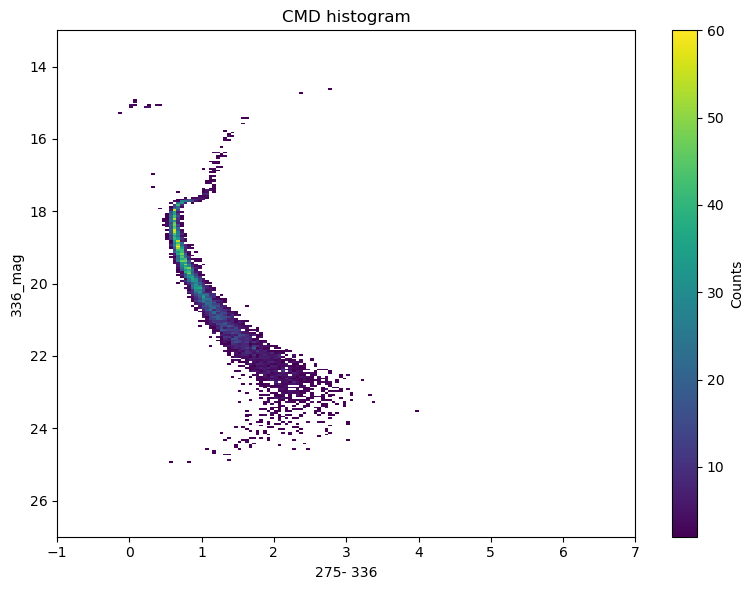

In [8]:
H_masked = np.ma.masked_where(H == 0, H)

plt.figure(figsize=(8, 6))

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(x_edges, y_edges, H_masked.T, shading='auto')

plt.colorbar(label="Counts")

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.title("CMD histogram")
plt.tight_layout()
plt.show()

### 3.3) get_max_width_bins
Extract the max width where there are counts for each horizontal line in the histogram.

- Allows small gaps (1 empty bin tolerance)
- Tracks consecutive regions
- Uses 'insured' segments to recover sequences
- Selects the widest valid MS segment

In [9]:
center_line = []
min_edge = []
max_edge = []

for column in H.T:

    indexes = []
    values = []

    stored_idx = []
    stored_val = []

    insured_idx = []
    insured_val = []

    width = 0
    insured_width = 0
    max_width = 0
    empty_count = 0

    for i, val in enumerate(column):

        if val > 0:
            empty_count = 0
            width += 1

            stored_idx.append(i)
            stored_val.append(val)

            insured_idx = []
            insured_val = []
            insured_width = 0

        else:
            empty_count += 1

            if empty_count < 2:
                # Save previous valid segment
                insured_idx = stored_idx.copy()
                insured_val = stored_val.copy()
                insured_width = width

                # Extend segment including gap
                width += 1
                stored_idx.append(i)
                stored_val.append(val)

            else:
                # Evaluate insured segment
                if insured_width > max_width and insured_width >= min_step:
                    indexes = insured_idx
                    values = insured_val
                    max_width = insured_width

                # Reset everything
                stored_idx = []
                stored_val = []
                insured_idx = []
                insured_val = []
                width = 0
                insured_width = 0

    # Final assignment
    if len(indexes) > 0:
        min_edge.append(indexes[0])
        max_edge.append(indexes[-1])

        weighted_mean = np.average(indexes, weights=values)
        center_line.append(weighted_mean)
    else:
        min_edge.append(0)
        max_edge.append(0)
        center_line.append(0)

#### Plotting min, max and center line

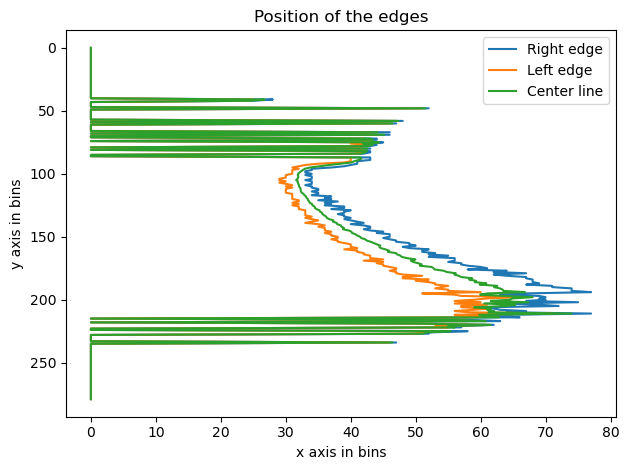

In [10]:
# Plots the boundaries and center line of the MS, but they are not filtered
plt.plot(max_edge, range(bins[1]), label = "Right edge")
plt.plot(min_edge, range(bins[1]), label = "Left edge")
plt.plot(center_line, range(bins[1]), label = "Center line")

plt.xlabel("x axis in bins")
plt.ylabel("y axis in bins")

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.title("Position of the edges")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4) extract_main_sequence
Extract main sequence using the center line in the bin space and returns its boundaries.

The main sequence is defined as the longest contiguous segment of non-zero values in the center line.

In [11]:
center_line = np.array(center_line)
min_edge = np.array(min_edge)
max_edge = np.array(max_edge)

# --- Find zero positions ---
zero_idx = np.where(center_line == 0)[0]

# Edge case: no zeros → entire range is MS
if len(zero_idx) < 2:
    start = 0
    main_sequence = np.arange(len(center_line))
else:
    # --- Find largest gap between zeros ---
    gaps = zero_idx[1:] - zero_idx[:-1] - 1

    max_gap_idx = np.argmax(gaps)
    max_width = gaps[max_gap_idx]
    start = zero_idx[max_gap_idx]

    main_sequence = np.arange(start + 1, start + max_width)

# --- Extract MS in bin space ---
filtered_center = center_line[main_sequence]
filtered_min = min_edge[main_sequence]
filtered_max = max_edge[main_sequence]

# --- Convert to magnitude space ---
offset = 1 / (2 * bins_division)

normalized_min = filtered_min / bins_division + xmin + offset
normalized_max = filtered_max / bins_division + xmin + offset
normalized_center = filtered_center / bins_division + xmin + offset

main_sequence_y = main_sequence / bins_division  + ymin + offset

MS_index_start = start + 1

#### Plotting Main Sequence

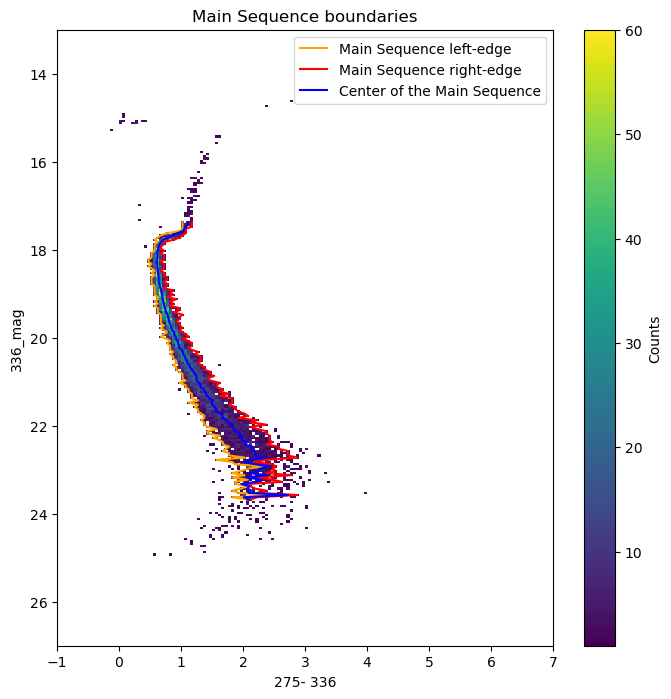

In [12]:
plt.figure(figsize = (8, 8))

#Plotting the boundaries and center line of the Main Sequence
plt.plot(normalized_min, main_sequence_y, c = "orange", label = "Main Sequence left-edge")
plt.plot(normalized_max, main_sequence_y, c = "red", label = "Main Sequence right-edge")
plt.plot(normalized_center, main_sequence_y, c = "blue", label = "Center of the Main Sequence")

cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence boundaries")
plt.colorbar(label='Counts')
plt.legend()

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.show()

### 3.5) smooth_sequence

Smooth the extracted Main Sequence boundaries using a Savitzky-Golay filter.

The smoothing helps produce a more continuous and physically meaningful
representation of the MS in the Color-Magnitude Diagram (CMD).

In [13]:
from scipy.signal import savgol_filter


normalized_min = np.array(normalized_min)
normalized_max = np.array(normalized_max)
normalized_center = np.array(normalized_center)

window = max(5, int(len(normalized_min)/3) | 1)  # Window size for Savitzky-Golay filter (must be odd)

poly = min(10, window - 1)

min_smooth = savgol_filter(normalized_min, window, poly)
max_smooth = savgol_filter(normalized_max, window, poly)
center_smooth = savgol_filter(normalized_center, window, poly)

#### Plotting the smoothed boundaries

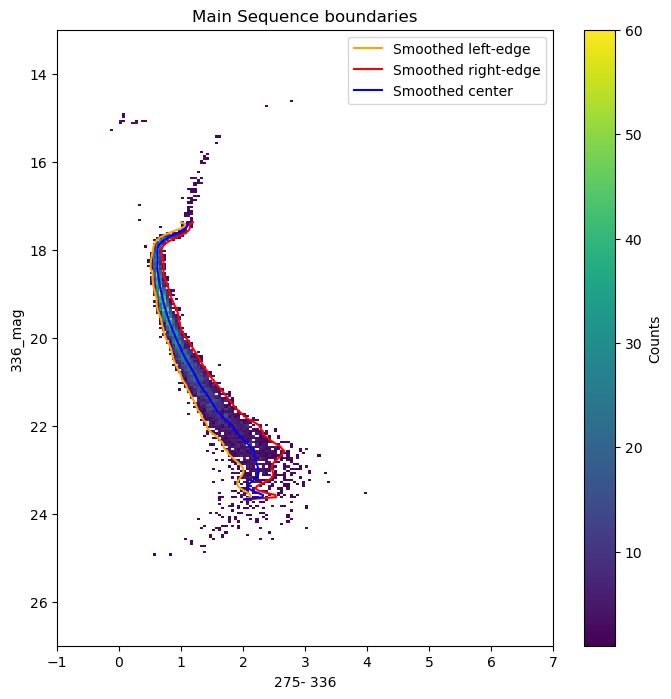

In [14]:
plt.figure(figsize = (8, 8))

# Plotting the smothed boundaries and center line of the main sequence
plt.plot(min_smooth, main_sequence_y, c = "orange", label = "Smoothed left-edge")
plt.plot(max_smooth, main_sequence_y, c = "red", label = "Smoothed right-edge")
plt.plot(center_smooth, main_sequence_y, c = "blue", label = "Smoothed center")

cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # values below vmin will be white

# Plot using pcolormesh (better for histograms)
plt.pcolormesh(
    x_edges, y_edges, H.T,
    cmap=cmap,
    vmin=1  # everything <1 (i.e. 0) becomes white
)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence boundaries")
plt.colorbar(label='Counts')
plt.legend()

# Invert Y-axis (important for CMDs!)
plt.gca().invert_yaxis()

plt.show()

### 3.6) detect_msto

Detect the Main Sequence Turn-Off (MSTO) point from the smoothed main sequence center line.

The MSTO is identified as the point where the main sequence stops decreasing in magnitude and begins to turn toward the red (i.e., where the slope of the sequence changes sign).

In [15]:
derivative = np.diff(center_smooth)

negative = np.where(derivative <= 0)[0]

if len(negative) == 0:
    index_MSTO = 0
    msto_y = main_sequence_y[0]
else:
    # Geth the first index where the derivative changes from negative to positive
    index_MSTO = next((i for i, x in enumerate(np.diff(np.append(negative, negative[-1]))) if x != 1), -1)
    
    offset = 1 / (2 * bins_division)
    
    msto_y = (index_MSTO + MS_index_start) / bins_division + ymin + offset

### 3.7) We limit the length of the MSTO and SGB to avoid misclassifications

Detect the Main Sequence Turn-Off (MSTO) point from the smoothed
main sequence ridge line.

The MSTO is identified as the point where the main sequence stops
decreasing in magnitude and begins to turn toward the red (i.e.,
where the slope of the sequence changes sign).

This is done by computing the discrete derivative of the smoothed
central ridge (center_smooth) and locating the first transition
from non-positive to positive slope.

Points G and I will be used later.

In [16]:
# Convert physical height → index space
max_msto_idx = int(maximum_lenght_MSTO * bins_division)

# Define SGB start (half of MSTO window below MSTO)
half_window = max_msto_idx // 2
index_SGB = max(0, index_MSTO - half_window)

# If MSTO is too deep in the sequence → trim lower part
if index_MSTO > max_msto_idx:

    shift = index_MSTO - max_msto_idx

    # Trim arrays
    main_sequence_y = main_sequence_y[shift:]
    min_smooth = np.asarray(min_smooth)[shift:]
    max_smooth = np.asarray(max_smooth)[shift:]

    # Adjust indices
    index_MSTO -= shift
    index_SGB -= shift

# --- Points G and H ---
point_G = [max_smooth[index_MSTO], msto_y]
point_I = [min_smooth[index_MSTO], msto_y]

#### Plotting the MS with the start of the Main Sequence Turn Off (MSTO) and Red Giant Branch RGB

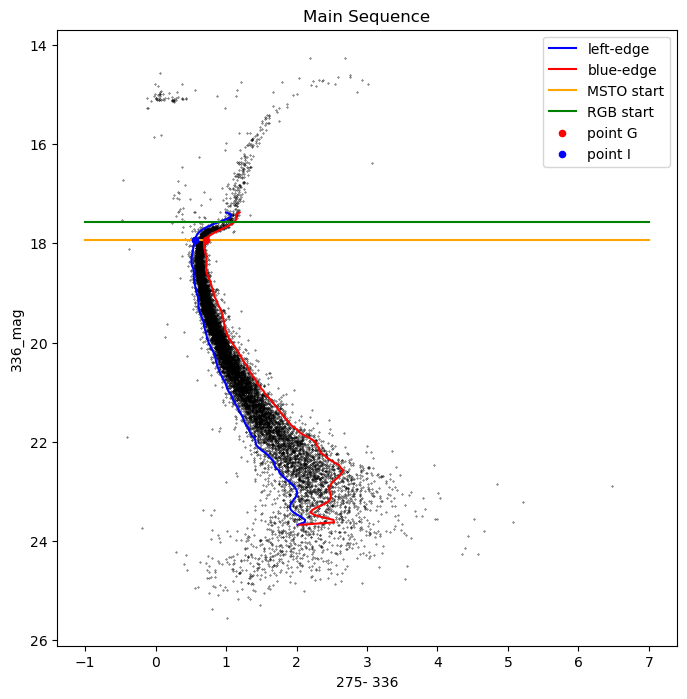

In [17]:
plt.figure(figsize = (8, 8))

# Ploting the boundaries and dividing lines of the MS, MSTO and RGB
plt.plot(min_smooth, main_sequence_y, c = "blue", label = "left-edge")
plt.plot(max_smooth, main_sequence_y, c = "red", label = "blue-edge")
plt.plot(ranges[0], [main_sequence_y[index_MSTO], main_sequence_y[index_MSTO]], c = "orange", label = "MSTO start")
plt.plot(ranges[0], [main_sequence_y[index_SGB], main_sequence_y[index_SGB]], c = "green", label = "RGB start")

# PLotting all sources
plt.scatter(df[f"{Color1} - {Color2}"], df[f"{Color2}_Mag"], c = "black", s = 0.1)

# Point left and right edge of the MSTO (points I and G)
plt.scatter(point_G[0], point_G[1], color='red', s=20, label='point G', zorder=10)
plt.scatter(point_I[0], point_I[1], color='blue', s=20, label='point I', zorder=10)

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")

plt.title("Main Sequence")
plt.legend()

plt.gca().invert_yaxis()
plt.show()

# Step 4: classify_optical_data
Classify stars based on their position relative to the main sequence
### 4.1) classify_position_MS
Classify stars based on their position relative to the Main Sequence (MS).

- The classification is done segment-by-segment using interpolated MS boundaries.

- The classification also depends on the position with respect to the MSTO and SGB

In [18]:
x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{graphic_comp}"

df[pos_col] = "Unknown"

x_vals = df[x_col].values
y_vals = df[y_col].values

# --- Loop over MS segments ---
for i in range(len(main_sequence_y) - 1):

    xmin_1, xmin_2 = min_smooth[i], min_smooth[i + 1]
    xmax_1, xmax_2 = max_smooth[i], max_smooth[i + 1]
    y1, y2 = main_sequence_y[i], main_sequence_y[i + 1]

    slope = (xmin_2 - xmin_1) / (y2 - y1)

    mask = (y_vals >= y1) & (y_vals < y2)

    if not np.any(mask):
        continue

    y_seg = y_vals[mask]
    x_seg = x_vals[mask]

    # --- Interpolate MS boundaries ---
    x_min_real = xmin_1 + (y_seg - y1) * slope
    x_max_real = xmax_1 + (y_seg - y1) * slope

    # --- Define thresholds ---
    conditions = [
        x_seg < x_min_real - significantly_bluer_limit,
        x_seg < x_min_real - bluer_limit,
        x_seg < x_min_real,
        x_seg < x_max_real,
        x_seg < x_max_real + redder_limit,
        x_seg < x_max_real + significantly_redder_limit,
    ]

    # --- Choose labels depending on region ---
    if i < index_SGB:
        labels = [
            "bluer than MS L3",
            "bluer than MS L2",
            "bluer than SGB",
            "Sub Giant Branch",
            "redder than SGB",
            "redder than MS L2",
        ]

    elif i < index_MSTO:
        labels = [
            "bluer than MS L3",
            "bluer than MS L2",
            "bluer than MSTO",
            "MSTO",
            "redder than MSTO",
            "redder than MS L2",
        ]

    else:
        labels = [
            "bluer than MS L3",
            "bluer than MS L2",
            "bluer than MS L1",
            "MS",
            "redder than MS L1",
            "redder than MS L2",
        ]

    result = np.select(conditions, labels, default="redder than MS L3")

    df.loc[mask, pos_col] = result

# --- Below MS ---
df.loc[y_vals > main_sequence_y[-1], pos_col] = "below the MS"


#### Graphical representation of all classified sources

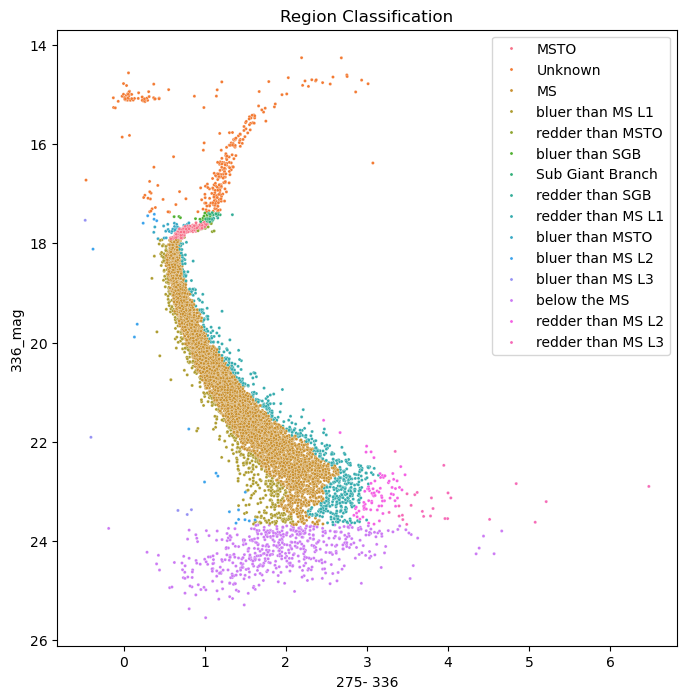

In [19]:
plt.figure(figsize = (8, 8))

# Plotting all classified sources with different colors
sns.scatterplot(data = df, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{graphic_comp}", s = 5)
plt.gca().invert_yaxis()


plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("Region Classification")
plt.legend()

plt.show()

### 4.2) create_4_regions
Split optical sources into 4 regions based on CMD geometry. It is easier to classify them in separate regions than all together.

Regions:
- R1: Below main sequence
- R2: Between MS and MSTO
- R3: Right side (RGB / AGB candidates)
- R4: Left side (HB / BS candidates)

R3 and R4 are separated by a line formed between the top left of the MS (point A) and the top left of the RGB or MSTO (point B). But they are not blindly classified, if a source that is already classified as MSTO or RGB, they will belong to the region 3 even if they are at the left of the line.

In [20]:
x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{graphic_comp}"

# --- Extract arrays ---
x = df[x_col].values
y = df[y_col].values
pos = df[pos_col].values

# --- Key MS points ---
idx_A = np.argmax(main_sequence_y == msto_y)

x_A = min_smooth[idx_A]
y_A = msto_y

x_B = min_smooth[0]
y_B = main_sequence_y[0]

y_max_ms = main_sequence_y[-1]

# --- Line A → B ---
slope = (x_B - x_A) / (y_B - y_A)
x_boundary = x_A + slope * (y - y_A)
#print(msto_y)
# --- Masks ---
mask_r1 = y >= y_max_ms

mask_r2 = (y < y_max_ms) & (y >= y_A)

mask_upper = (y < y_A) & (y >= y_B)
mask_lower = y < y_B

mask_sgb_msto = (pos == "Sub Giant Branch") | (pos == "MSTO")

mask_r3 = (
    (mask_upper & (x > x_boundary)) |
    (mask_lower & (x > x_B)) |
    mask_sgb_msto
)

mask_r4 = (
    ((mask_upper & (x <= x_boundary)) |
     (mask_lower & (x <= x_B))) &
    (~mask_sgb_msto)
)

# --- Create regions ---
region1 = df[mask_r1]
region2 = df[mask_r2]
region3 = df[mask_r3]
region4 = df[mask_r4]

#### Graphical representation of all classified sources

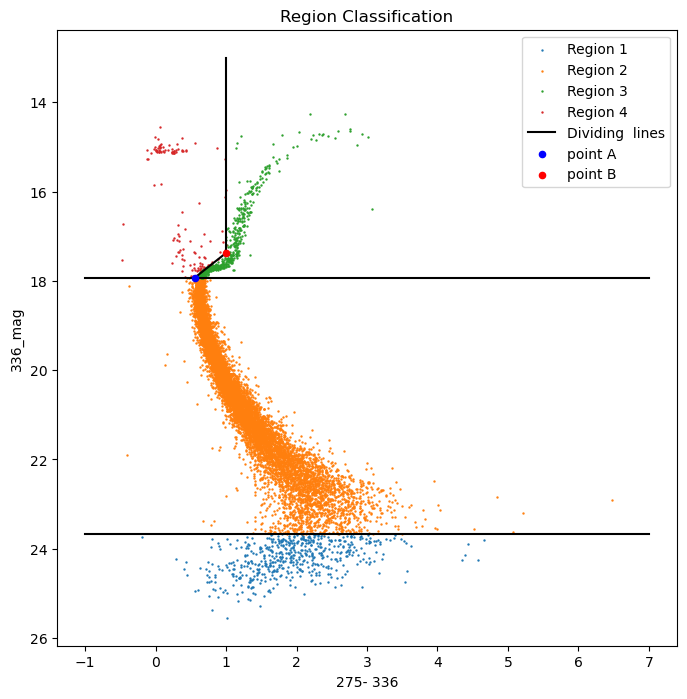

In [21]:
plt.figure(figsize = (8, 8))

# Plotting all 4 regions
plt.scatter(region1[x_col], region1[y_col], s=0.5, label='Region 1')
plt.scatter(region2[x_col], region2[y_col], s=0.5, label='Region 2')
plt.scatter(region3[x_col], region3[y_col], s=0.5, label='Region 3')
plt.scatter(region4[x_col], region4[y_col], s=0.5, label='Region 4')

# Dividing lines
plt.plot([x_A, x_B], [y_A, y_B], c = "black", label = "Dividing  lines")
plt.plot(ranges[0], [y_A, y_A], c = "black")
plt.plot([x_B, x_B], [y_B, ranges[1][0]], c = "black")
plt.plot(ranges[0], [main_sequence_y[-1], main_sequence_y[-1]], c = "black")

# Points A and B
plt.scatter(x_A, y_A, s=20, c = "blue", label='point A', zorder=10)
plt.scatter(x_B, y_B, s=20, c = "red", label='point B', zorder=10)

plt.gca().invert_yaxis()

plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("Region Classification")
plt.legend()

plt.show()



### 4.3) HB_classification
Take the region 4 and identify Horizontal Branch (HB) stars using DBSCAN clustering.

Steps:
- Apply DBSCAN clustering in CMD space
- Select the cluster located at the top-left (bright + blue)
- Label that cluster as HB
- Return bounding points: bottom left (point C), top left (point D) and bottom right (point E) of the HB


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

eps=0.4
min_samples=15

x_col = f"{Color1} - {Color2}"
y_col = f"{Color2}_Mag"
pos_col = f"position_{graphic_comp}"

x = region4[x_col].values
y = region4[y_col].values

# --- Prepare data ---
X = np.column_stack((x, y))
X_scaled = StandardScaler().fit_transform(X)

# --- Clustering ---
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
labels = db.labels_

# --- Get valid clusters (exclude noise) ---
clusters = [l for l in set(labels) if l != -1]

# --- Edge case: no clusters ---
if len(clusters) == 0:
    pass

# --- Select cluster ---
elif len(clusters) == 1:
    selected_label = clusters[0]
else:
    best_label = None
    best_score = None

    for label in clusters:
        mask = labels == label

        x_mean = np.mean(x[mask])
        y_mean = np.mean(y[mask])

        # TOP-LEFT → minimize x and y
        score = 2 * x_mean + y_mean

        if best_score is None or score < best_score:
            best_score = score
            best_label = label

    selected_label = best_label

# --- Extract selected cluster ---
mask = labels == selected_label

x_sel = x[mask]
y_sel = y[mask]

# --- Define bounding points, they will be used later ---
point_C = [x_sel.min(), y_sel.max()]
point_D = [x_sel.max(), y_sel.min()]
point_E = [x_sel.max(), y_sel.max()]

# --- Assign labels ---
region4.loc[mask, pos_col] = "HB"

### Plotting region 4

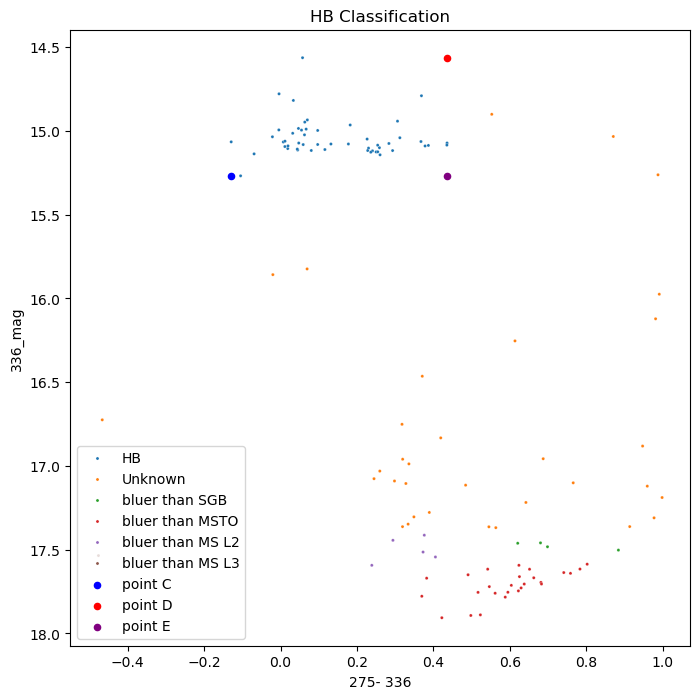

In [23]:
plt.figure(figsize = (8, 8))

# Plotting the classified sources of region 4
sns.scatterplot(data = region4, x = f"{Color1} - {Color2}", y = Color2 + "_Mag", hue = f"position_{graphic_comp}", s = 5)
plt.gca().invert_yaxis()

# Point left and right edge of the MSTO (points I and G)
plt.scatter(point_C[0], point_C[1], color='blue', s=20, label='point C', zorder=10)
plt.scatter(point_D[0], point_D[1], color='red', s=20, label='point D', zorder=10)
plt.scatter(point_E[0], point_E[1], color='purple', s=20, label='point E', zorder=10)


plt.xlabel(f"{Color1}- {Color2}")
plt.ylabel(f"{Color2}_mag")
plt.title("HB Classification")
plt.legend()

plt.show()